In [3]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
INPUT_PATH = '/content/drive/MyDrive/y3s2/SRIP'

In [6]:
df = pd.read_parquet(os.path.join(INPUT_PATH, 'data/Cohort2510_with_features.parquet'))
weekly_activity = pd.read_parquet(os.path.join(INPUT_PATH, 'data/weekly_activity.parquet'))
students_df = pd.read_csv(os.path.join(INPUT_PATH, 'csvs from posthog/Students.csv'))
assignments_df = pd.read_parquet(os.path.join(INPUT_PATH, 'data/assignments.parquet'))

In [31]:
# Convert 'due_date' in assignments_df to datetime objects
assignments_df['due_date'] = pd.to_datetime(assignments_df['due_date'])

## Context
### Description:
The following files are used for the charts below:

| Dataframe | Description |
| -------- | -------- |
| df | All events from the 2510 cohort, with reconstructed study sessions |
| weekly_activity | A summary of student activity on the website across each week in the academic calendar --> each row corresponds to a student's activity in a particular week |
| students_df | All students, including the fields `name` and `distinct_id` (also in df) |
| assignments_df | All assignments, including the fields `assignment`, `due_date` & `assignment_type` (paper/exercise) |

### Limitations
1. Study sessions are not actual approximates of student study periods. They are reconstructed by timestamps; as such, they may not accurately reflect student perspectives.
2. Study session durations are only proxies for student engagement/learning. Engagement with the website != actual learning.
3. There are some structural issues with data that affects session duration (e.g. tab switching might lead to overestimation of session duration).  

## 0. Preprocessing: Filtering `students_df`

`df` & `weekly_activity` are separated by cohort : Filter `students_df` to only include students who are found in those dataframes.

In [7]:
unique_distinct_ids_in_df = df['distinct_id'].unique()
students_df = students_df[students_df['distinct_id'].isin(unique_distinct_ids_in_df)]
students_df.sort_values(by='distinct_id')

,name,distinct_id
12,AshleyGohYuTing,26
6,BansalNaman,28
11,BennettHoChengXun,29
10,ChanEugene,30
4,ChiaChengXuXavier,31
45,ChowdhuryTia,32
42,DishaShivaraman,33
44,EthanDhirenDivyanathan,34
16,GuoRuiTing,35
7,GuptaNavya,36


In [105]:
## Checking that every student has some events
for id in unique_distinct_ids_in_df:
  print(f'ID {id}: {len(df[df['distinct_id'] == id])} events')


ID 38: 2332 events
ID 42: 2794 events
ID 26: 1848 events
ID 31: 2643 events
ID 41: 271 events
ID 50: 1351 events
ID 49: 2622 events
ID 30: 975 events
ID 35: 2627 events
ID 46: 2183 events
ID 29: 1573 events
ID 47: 1558 events
ID 45: 163 events
ID 40: 3046 events
ID 34: 1249 events
ID 48: 2155 events
ID 39: 1755 events
ID 33: 2637 events
ID 43: 214 events
ID 32: 1292 events
ID 36: 38 events
ID 28: 704 events
ID 37: 818 events
ID 44: 2150 events


## 0.5. Helper functions

### 0.5.1. `calculate_student_activity_summary(df_subset, days_col)`

- Takes in: Dataframe of a subset of all events associated with a **student** & the number of days left to an exercise/paper's due date
- Output: Average session duration & session counts for the student each day.

In [ ]:
def calculate_student_activity_summary(df_subset, days_col):
  df_subset = df_subset.copy()

  if not df_subset.empty:
    df_subset[days_col] = df_subset[days_col].astype(int)
  else:
    print('df_subset is empty')

  summary = df_subset.groupby(days_col).agg(
    avg_session_duration=('study_session_duration', 'mean'),
    total_session_count=('study_session_id', 'nunique')
  ).reset_index()

  max_gap = 19 if 'exercise' in days_col.lower() else 27
  all_days = range(0, max_gap + 1)

  summary = (
    summary
    .set_index(days_col)
    .reindex(all_days, fill_value=0) ## Fill missing days with 0 activity
    .rename_axis(days_col)
    .reset_index()
  )
  return summary

### 0.5.2. `calculate_cohort_activity_summary(df_subset, days_col)`

- Takes in: Dataframe of a subset of all events associated with an **assignment** & the number of days left to an exercise/paper's due date

- Output: Average session duration & session counts across all students each day, for the assignment.  

In [ ]:
def calculate_cohort_activity_summary(df_subset, days_col):
  df_subset = df_subset.copy()

  if not df_subset.empty:
    df_subset[days_col] = df_subset[days_col].astype(int)
  else:
    print('df_subset is empty')

  ## Each student's avg activity for each day left to due date
  per_student_agg = (
      df_subset.groupby(['distinct_id', days_col]).agg(
          avg_session_duration=('study_session_duration', 'mean'),
          total_session_count=('study_session_id', 'nunique')
      ).reset_index()
  )
  ## For each day, get avg overall student activity
  per_day_avg = (
      per_student_agg.groupby(days_col).agg(
          avg_session_duration=('avg_session_duration', 'mean'),
          total_session_count=('total_session_count', 'mean')
      ).reset_index()
  )
  max_gap = 19 if 'exercise' in days_col.lower() else 27
  all_days = range(0, max_gap + 1)

  summary = (
    per_day_avg
    .set_index(days_col)
    .reindex(all_days, fill_value=0) ## Fill missing days with 0 activity
    .rename_axis(days_col)
    .reset_index()
  )
  return summary

## 1. Plotting per-student activity (session count && session duration)

The function `plot_student_activity` takes a `distinct_id` as input and generates a dual-axis chart. For the student with that `distinct_id`, the chart displays total session count and average session duration across each course week.


In [8]:
def plot_student_activity(distinct_id_to_plot):
  student_data = weekly_activity[weekly_activity['distinct_id'] == distinct_id_to_plot]

  if student_data.empty:
      print(f"No data found for student with distinct_id: {distinct_id_to_plot}")
      return

  student_name = distinct_id_to_plot
  if ('name' in student_data.columns):
    student_name = student_data['name'].iloc[0]

  ## Sort by course_week (just in case)
  student_data = student_data.sort_values('course_week')

  fig, ax1 = plt.subplots(figsize=(12, 7))

  ## Average session duration on the first y-axis (left)
  ax1.bar(student_data['course_week'].astype(str), student_data['avg_weekly_duration'], color='blue', alpha=0.7, label='Average Session Duration (s)')
  ax1.set_xlabel('Course Week')
  ax1.set_ylabel('Average Session Duration (seconds)', color='skyblue')
  ax1.tick_params(axis='y', labelcolor='skyblue')
  ax1.set_title(f'Student {student_name}: Average Session Duration and Session Count per Course Week')
  ax1.set_xticklabels(student_data['course_week'].astype(str), rotation=45, ha='right')

  ## Session count on the second y-axis (right)
  ax2 = ax1.twinx()
  ax2.plot(student_data['course_week'].astype(str), student_data['weekly_session_count'], color='red', marker='o', linestyle='-', label='Session Count')
  ax2.set_ylabel('Session Count', color='red')
  ax2.tick_params(axis='y', labelcolor='red')

  fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

  fig.tight_layout()
  plt.show()


List of available students:
                       name  distinct_id
12         AshleyGohYuTing           26
6              BansalNaman           28
11       BennettHoChengXun           29
10              ChanEugene           30
4        ChiaChengXuXavier           31
45            ChowdhuryTia           32
42         DishaShivaraman           33
44  EthanDhirenDivyanathan           34
16              GuoRuiTing           35
7               GuptaNavya           36
13            IanTayQiShen           37
15         JoshuaSimJunHui           38
0                  KimAmin           39
43             KimYongchan           40
3              KongXinYang           41
1                LeeJaeYan           42
46             LimJingYuan           43
8               LinBo-Ruei           44
47          MarcusWeeYuZhe           45
2               NgYeeXiang           46
5                RenZhaoyi           47
14       SatapathyPulastya           48
9            SeetohYihKeet           49
17         

/tmp/ipykernel_3046/1174131133.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(student_data['course_week'].astype(str), rotation=45, ha='right')


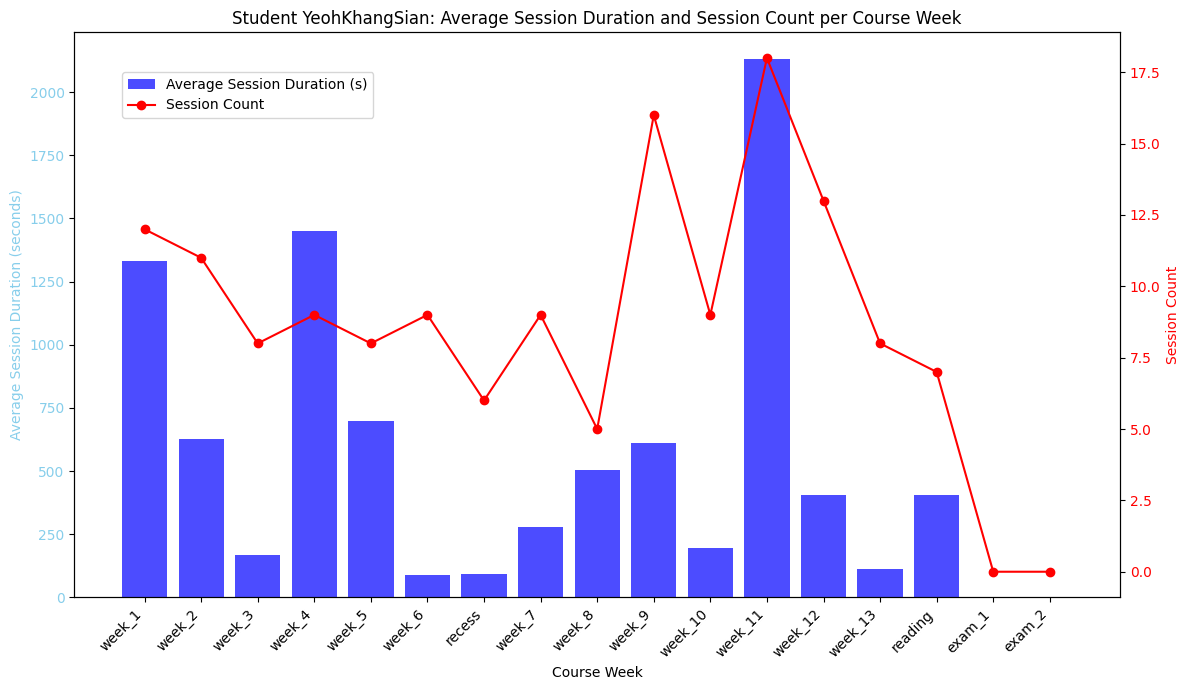

In [9]:
print(f'List of available students:\n {students_df.sort_values(by='distinct_id')}\n')
id = input("ID of student to plot: ")
plot_student_activity(int(id))

## 2. Activity Trends Around Due Dates

The function `plot_due_date_activity` takes a `distinct_id` as input and visualizes how the student's activity (average session duration and session count) changes in relation to the number of days from an exercise/paper due date.
- Exercises' maximum gap : 19 days
- Papers' maximum gap : 27 days

In [18]:
def plot(df_due_date_activity, student_name, col, assignment_type):
  ## Group by col (days_to_exercise_due OR days_to_paper_due)
  due_date_summary = df_due_date_activity.groupby(col).agg(
      avg_session_duration=('study_session_duration', 'mean'),
      total_session_count=('study_session_id', 'nunique')
  ).reset_index()

  ## Sort by col for chronological plotting
  due_date_summary = due_date_summary.sort_values(col)

  max_gap = 19 if 'exercise' in col else 27
  all_days = range(0, max_gap + 1)
  due_date_summary = (
      due_date_summary
      .set_index(col)
      .reindex(all_days, fill_value=0)
      .rename_axis(col)
      .reset_index()
  )

  fig, ax1 = plt.subplots(figsize=(14, 7))

  ## Average session duration on the first y-axis (left)
  ax1.bar(due_date_summary[col], due_date_summary['avg_session_duration'], color='lightcoral', alpha=0.7, label='Average Session Duration (s)')
  ax1.set_xlabel(f'Days from {assignment_type} Due Date')
  ax1.set_ylabel('Average Session Duration (seconds)', color='lightcoral')
  ax1.tick_params(axis='y', labelcolor='lightcoral')
  ax1.set_title(f'Student {student_name}: Activity Relative to {assignment_type} Due Date')

  ## Session count on the second y-axis (right)
  ax2 = ax1.twinx()
  ax2.plot(due_date_summary[col], due_date_summary['total_session_count'], color='darkgreen', marker='s', linestyle='--', label='Total Session Count')
  ax2.set_ylabel('Total Session Count', color='darkgreen')
  ax2.tick_params(axis='y', labelcolor='darkgreen')

  ## Add vertical line at 0 (due date)
  ax1.axvline(x=0, color='gray', linestyle=':', linewidth=2, label='Due Date')

  lines, labels = ax1.get_legend_handles_labels()
  lines2, labels2 = ax2.get_legend_handles_labels()
  ax2.legend(lines + lines2, labels + labels2, loc='upper left')

  fig.tight_layout()
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.show()


def plot_due_date_activity(distinct_id_to_plot):
  student_data = df[df['distinct_id'] == distinct_id_to_plot]

  if student_data.empty:
      print(f"No data found for student with distinct_id: {distinct_id_to_plot}")
      return

  student_name = distinct_id_to_plot
  if ('name' in student_data.columns):
    student_name = student_data['name'].iloc[0]

  ## Plotting days to exercise due date
  plot(student_data, student_name, 'days_to_exercise_due', 'Exercise')
  ## Plotting days to paper due date
  plot(student_data, student_name, 'days_to_paper_due', 'Paper')


List of available students:
                       name  distinct_id
12         AshleyGohYuTing           26
6              BansalNaman           28
11       BennettHoChengXun           29
10              ChanEugene           30
4        ChiaChengXuXavier           31
45            ChowdhuryTia           32
42         DishaShivaraman           33
44  EthanDhirenDivyanathan           34
16              GuoRuiTing           35
7               GuptaNavya           36
13            IanTayQiShen           37
15         JoshuaSimJunHui           38
0                  KimAmin           39
43             KimYongchan           40
3              KongXinYang           41
1                LeeJaeYan           42
46             LimJingYuan           43
8               LinBo-Ruei           44
47          MarcusWeeYuZhe           45
2               NgYeeXiang           46
5                RenZhaoyi           47
14       SatapathyPulastya           48
9            SeetohYihKeet           49
17         

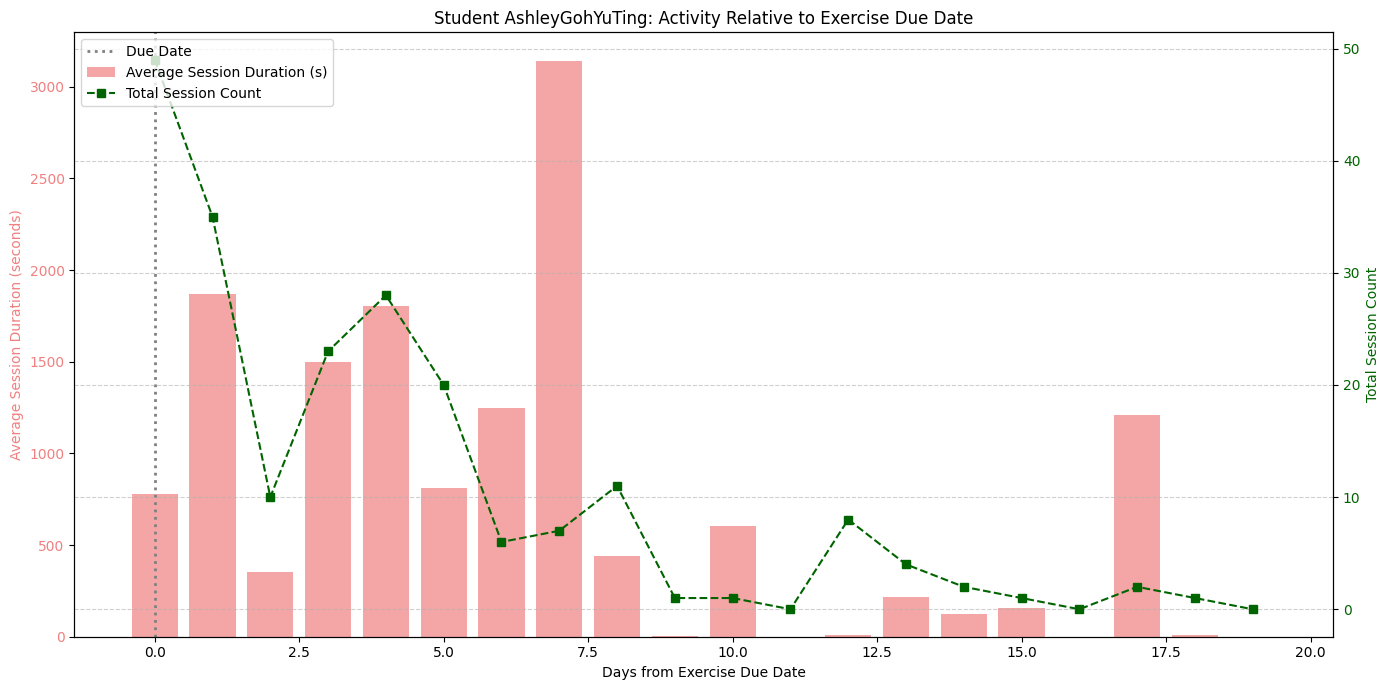

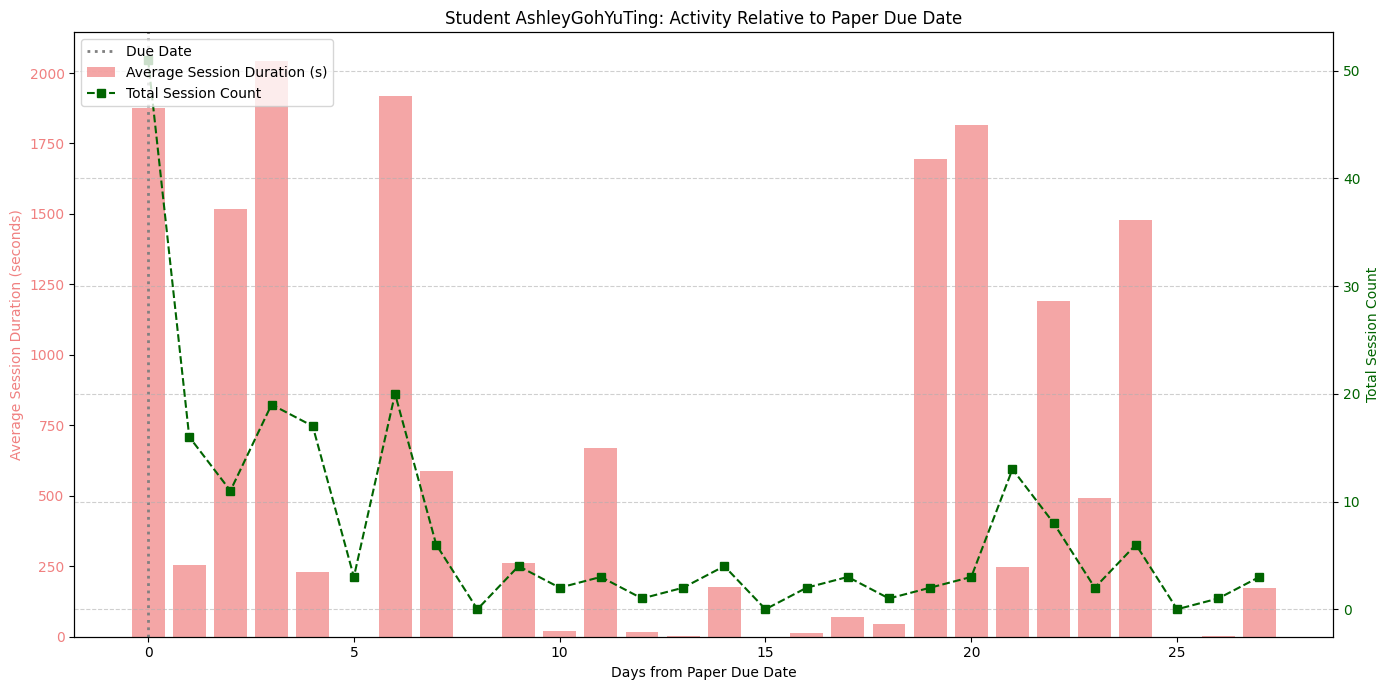

In [19]:
print(f'List of available students:\n {students_df.sort_values(by='distinct_id')}\n')
id = input("ID of student to plot: ")
plot_due_date_activity(int(id))

## 3. Activity Trend for Specific Assignments/Students

The function `plot_student_specific_assignment_activity` visualizes how a student's activity (average session duration & session count) for a specific assignment changes in relation to the number of days from the due date of a specific assignment. The chart shows average activity (avg session duration & avg session count) for the same assignment over all students for comparison.

In [89]:
def plot_comparison(student_summary, overall_summary, student_name, assignment, days_col_label):
  fig, ax1 = plt.subplots(figsize=(14, 7))

  ## Student vs overall - Average Session Duration (bars)
  index = np.arange(len(student_summary[days_col_label]))
  bar_width = 0.4

  ax1.bar(index - bar_width/2, student_summary['avg_session_duration'], bar_width,
          color='skyblue', alpha=0.7, label=f'{student_name} - Avg Session Duration')
  ax1.bar(index + bar_width/2, overall_summary['avg_session_duration'], bar_width,
          color='blue', alpha=0.7, label=f'Overall activity - Avg Session Duration')
  ax1.set_xlabel('Days from Due Date')
  ax1.set_ylabel('Average Session Duration (seconds)', color='skyblue')
  ax1.tick_params(axis='y', labelcolor='skyblue')
  ax1.set_title(f'Student {student_name} vs. Overall Average Activity for {assignment}')


  ## Student activity - Total Session Count (line)
  ax2 = ax1.twinx()
  ax2.plot(student_summary[days_col_label], student_summary['total_session_count'],
            color='darkblue', marker='o', linestyle='-', label=f'{student_name} - Total Session Count')
  ax2.set_ylabel('Total Session Count', color='darkblue')
  ax2.tick_params(axis='y', labelcolor='darkblue')

  ## Overall activity - Total Session Count (dotted line)
  ax2.plot(overall_summary[days_col_label], overall_summary['total_session_count'],
            color='darkred', linestyle=':', marker='^', linewidth=2, label=f'Overall activity - Avg Session Count')

  ax1.axvline(x=0, color='gray', linestyle=':', linewidth=2, label='Due Date')

  # Combine legends from both axes
  lines, labels = ax1.get_legend_handles_labels()
  lines2, labels2 = ax2.get_legend_handles_labels()
  ax2.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(1.05, 1))

  fig.tight_layout()
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.show()

In [90]:
def plot_student_specific_assignment_activity(distinct_id_to_plot, assignment, specific_due_date):
  student_data = df[df['distinct_id'] == distinct_id_to_plot].copy()

  if student_data.empty:
    print(f"No data found for student with distinct_id: {distinct_id_to_plot}")
    return

  student_name = distinct_id_to_plot
  if ('name' in student_data.columns):
    student_name = student_data['name'].iloc[0]

  ## Look up assignment type
  due_date_col = ''
  days_col = ''
  next_col = ''
  assignment_label = ''

  assignment_row = assignments_df[assignments_df['assignment'] == assignment]
  if assignment_row.empty:
      print(f"No assignment found with name: {assignment}")
      return
  assignment_type = assignment_row['assignment_type'].iloc[0]

  if assignment_type == 'exercise':
      due_date_col = 'next_exercise_due'
      days_col = 'days_to_exercise_due'
      next_col = 'next_exercise'
      assignment_label = 'Exercise'
  elif assignment_type == 'paper':
      due_date_col = 'next_paper_due'
      days_col = 'days_to_paper_due'
      next_col = 'next_paper'
      assignment_label = 'Paper'
  else:
      print("Invalid assignment_type.")
      return

  ## Ensure due date column in student_data is datetime
  if due_date_col in student_data.columns:
      student_data[due_date_col] = pd.to_datetime(student_data[due_date_col])

  ## Calculate student's activity summary for the assignment
  student_assignment_specific_data = student_data[student_data[due_date_col] == specific_due_date].copy()
  student_summary = calculate_student_activity_summary(student_assignment_specific_data, days_col)

  ## Calculate overall avg activity summary for the assignment
  overall_assignment_type_data = df[df[next_col] == assignment].copy()
  overall_assignment_type_data[due_date_col] = pd.to_datetime(overall_assignment_type_data[due_date_col])
  average_summary = calculate_cohort_activity_summary(overall_assignment_type_data, days_col)

  plot_comparison(student_summary, average_summary, student_name, assignment, days_col)


List of available students:
                       name  distinct_id
12         AshleyGohYuTing           26
6              BansalNaman           28
11       BennettHoChengXun           29
10              ChanEugene           30
4        ChiaChengXuXavier           31
45            ChowdhuryTia           32
42         DishaShivaraman           33
44  EthanDhirenDivyanathan           34
16              GuoRuiTing           35
7               GuptaNavya           36
13            IanTayQiShen           37
15         JoshuaSimJunHui           38
0                  KimAmin           39
43             KimYongchan           40
3              KongXinYang           41
1                LeeJaeYan           42
46             LimJingYuan           43
8               LinBo-Ruei           44
47          MarcusWeeYuZhe           45
2               NgYeeXiang           46
5                RenZhaoyi           47
14       SatapathyPulastya           48
9            SeetohYihKeet           49
17         

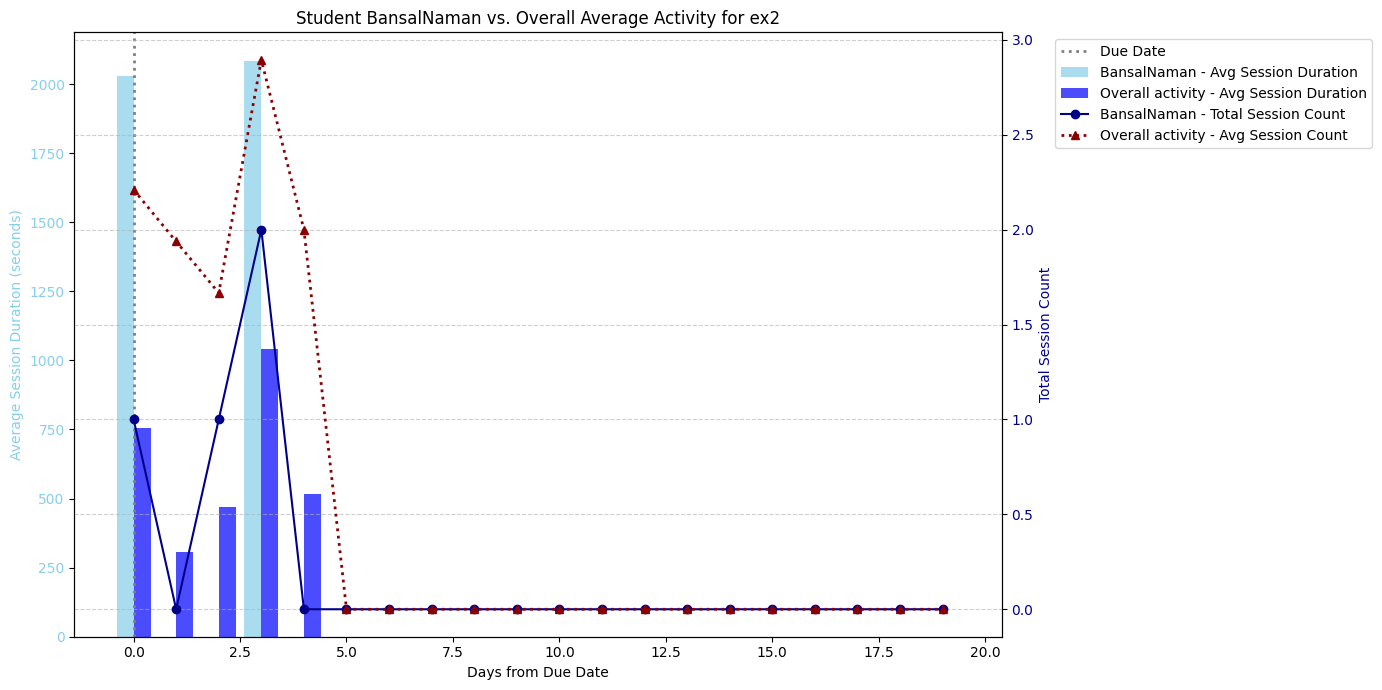

In [92]:
print(f'List of available students:\n {students_df.sort_values(by='distinct_id')}\n')
student_id_input = input("Enter the distinct_id of the student to plot: ")

print(f'\nList of available assignments:\n {assignments_df}\n')
selected_assignment_name = input("Enter the name of the assignment you want to plot (from the list): ")

try:
  student_id = int(student_id_input)
except ValueError:
  print("Invalid student ID. Please enter a number.")
  student_id = None

if student_id is not None:
  selected_assignment_row = assignments_df[assignments_df['assignment'] == selected_assignment_name]
  if not selected_assignment_row.empty:
    specific_due_date = selected_assignment_row['due_date'].iloc[0]
    plot_student_specific_assignment_activity(student_id, selected_assignment_name, specific_due_date)
  else:
    print(f"Assignment '{selected_assignment_name}' not found. Please choose from the list.")
